c:\Users\saiga\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


c:\Users\saiga\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:144: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\saiga\.cache\huggingface\hub\models--timm--densenet121.ra_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Total parameters: 93,802,370
Trainable parameters: 93,802,370
Starting training...


c:\Users\saiga\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


✓ New best model saved with accuracy: 88.33%
Epoch  1/50 | Train Loss: 0.4647 | Train Acc: 78.23% | Val Loss: 0.2911 | Val Acc: 88.33%
✓ New best model saved with accuracy: 89.38%
Epoch  2/50 | Train Loss: 0.2656 | Train Acc: 89.90% | Val Loss: 0.2762 | Val Acc: 89.38%
✓ New best model saved with accuracy: 90.42%
Epoch  3/50 | Train Loss: 0.2266 | Train Acc: 91.25% | Val Loss: 0.2851 | Val Acc: 90.42%
✓ New best model saved with accuracy: 91.25%
Epoch  4/50 | Train Loss: 0.1921 | Train Acc: 93.28% | Val Loss: 0.2452 | Val Acc: 91.25%
✓ New best model saved with accuracy: 93.33%
Epoch  5/50 | Train Loss: 0.1852 | Train Acc: 94.58% | Val Loss: 0.2256 | Val Acc: 93.33%
Epoch  6/50 | Train Loss: 0.1698 | Train Acc: 94.48% | Val Loss: 0.2996 | Val Acc: 92.08%
✓ New best model saved with accuracy: 93.75%
Epoch  7/50 | Train Loss: 0.1337 | Train Acc: 96.20% | Val Loss: 0.2786 | Val Acc: 93.75%
Epoch  8/50 | Train Loss: 0.1115 | Train Acc: 97.19% | Val Loss: 0.2342 | Val Acc: 91.46%
Epoch  9/5

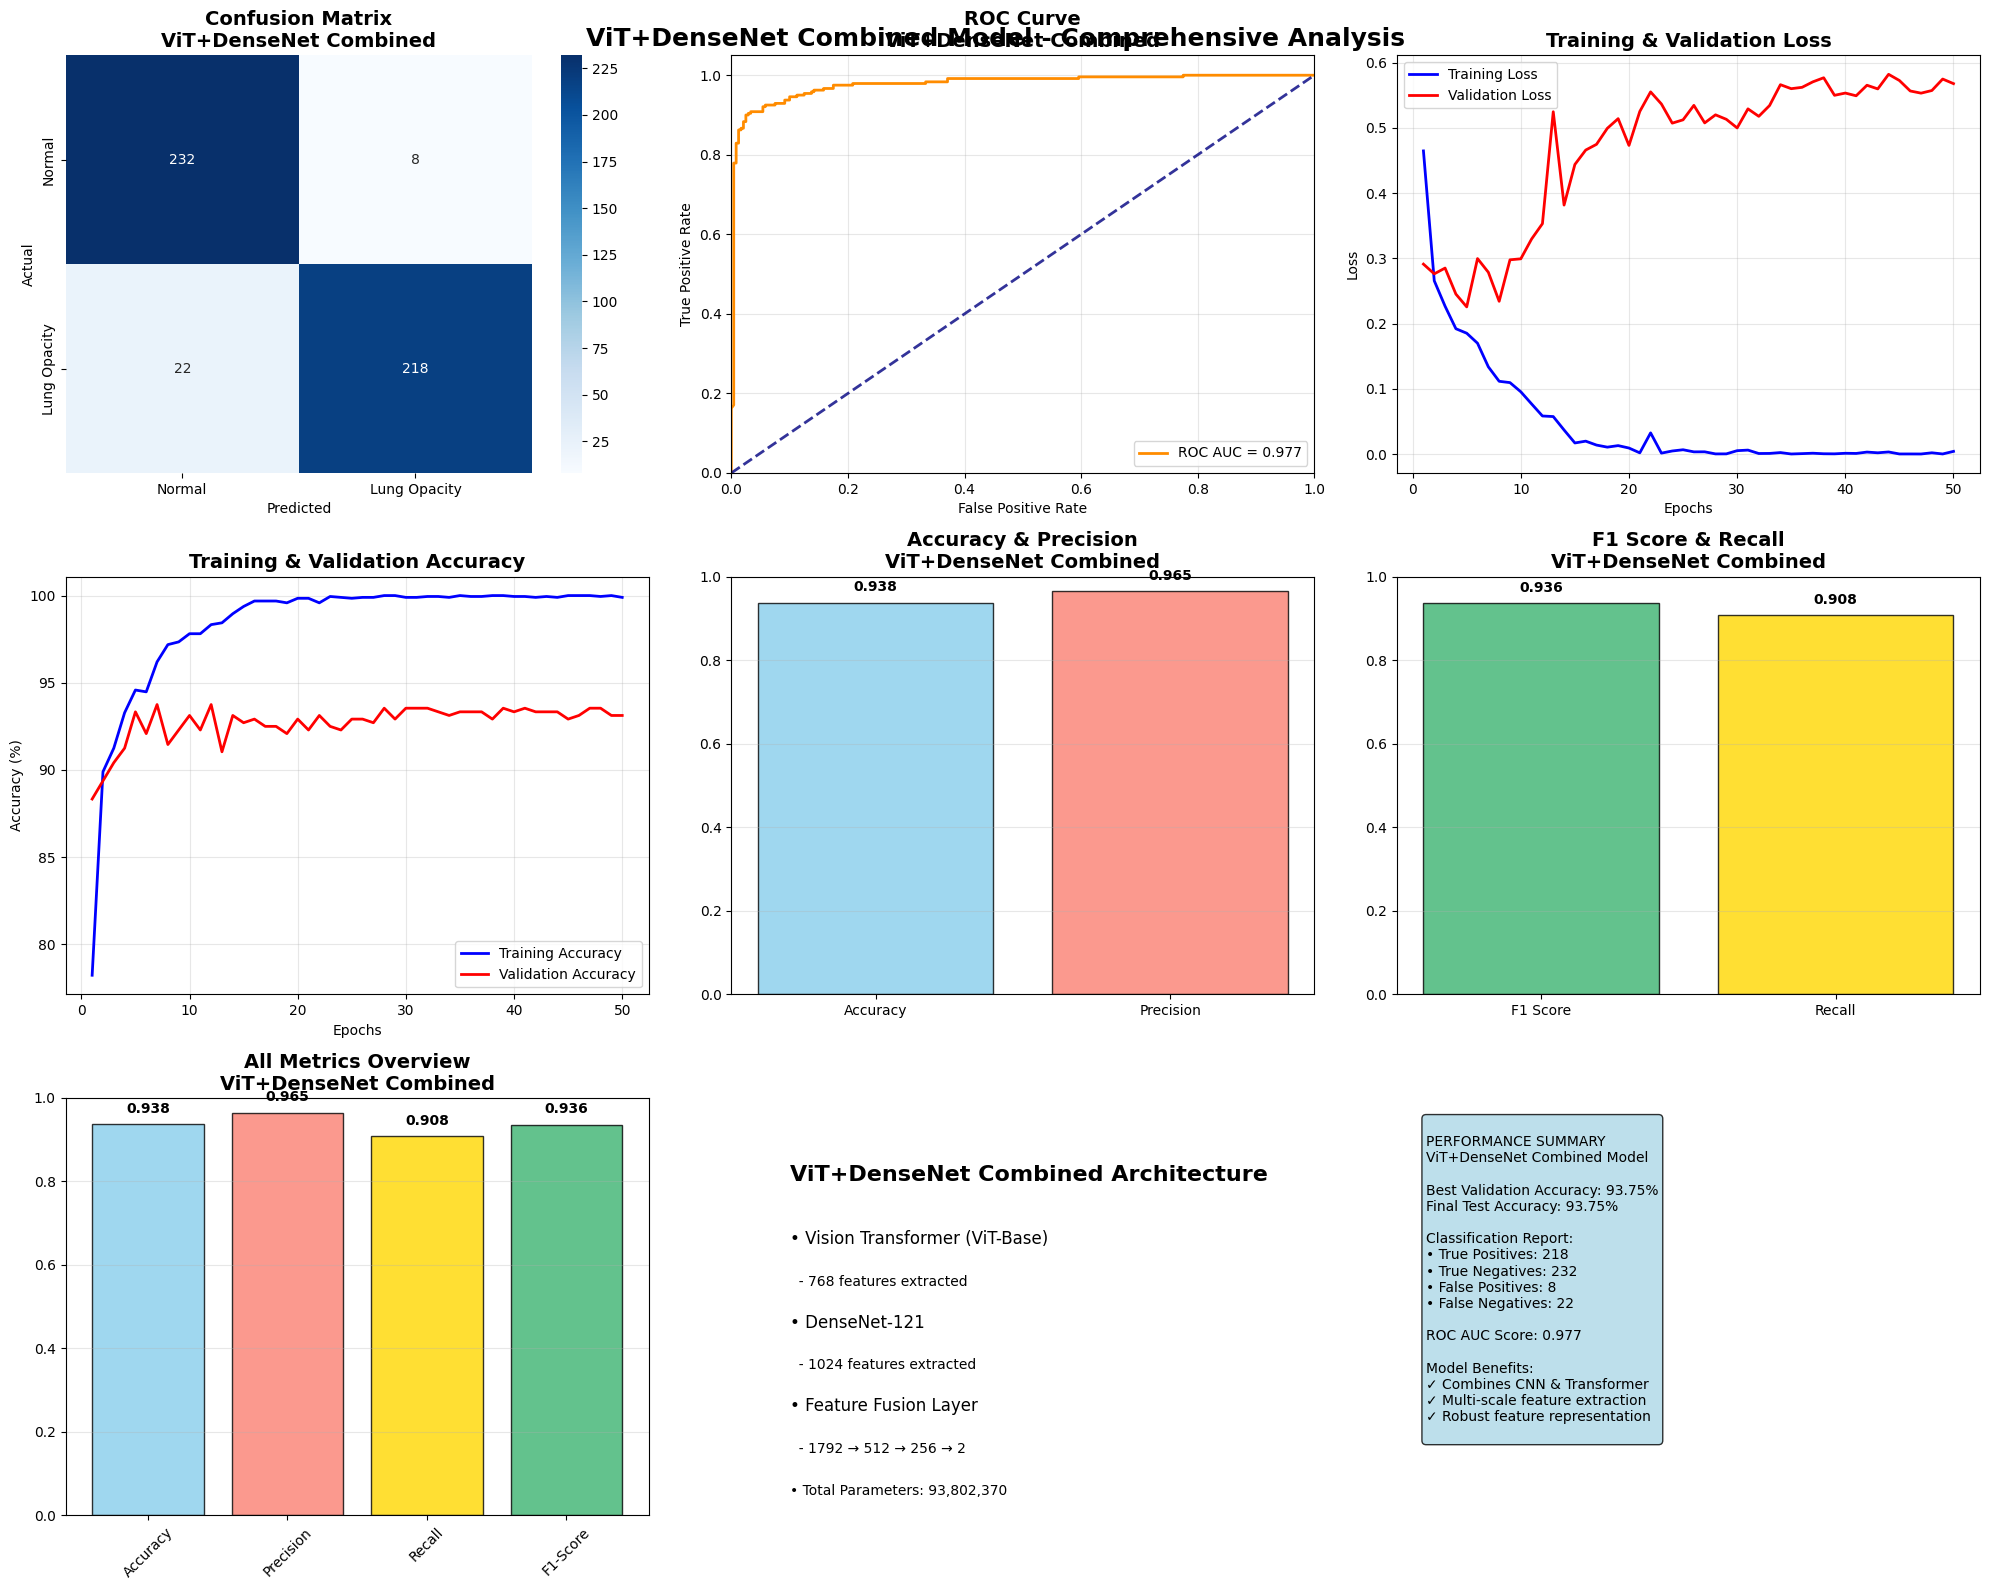


Model saved as: best_vit_densenet_model.pth
Training completed successfully!
Results summary: {'model': 'ViT+DenseNet Combined', 'final_accuracy': 0.9375, 'best_validation_accuracy': 0.9375, 'precision': 0.9646017699115044, 'recall': 0.9083333333333333, 'f1_score': 0.9356223175965666, 'roc_auc': np.float64(0.9773611111111112), 'total_parameters': 93802370, 'trainable_parameters': 93802370}


In [1]:
#VIT+DENSENET


import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, auc
)
import timm
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch.nn.functional as F
import cv2
import random

# Dataset class
class ChestXrayDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label, img_path

# Combined ViT + DenseNet Model
class ViTDenseNetCombined(nn.Module):
    def __init__(self, num_classes=2, dropout_rate=0.3):
        super(ViTDenseNetCombined, self).__init__()
        
        # Vision Transformer branch
        self.vit = timm.create_model('vit_base_patch16_224', pretrained=True)
        vit_features = self.vit.head.in_features
        self.vit.head = nn.Identity()  # Remove the classification head
        
        # DenseNet branch
        self.densenet = timm.create_model('densenet121', pretrained=True)
        densenet_features = self.densenet.classifier.in_features
        self.densenet.classifier = nn.Identity()  # Remove the classification head
        
        # Feature fusion layer
        combined_features = vit_features + densenet_features
        
        # Classification head with fusion
        self.fusion_layer = nn.Sequential(
            nn.Linear(combined_features, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )
        
        # Alternative: Attention-based fusion (uncomment to use)
        # self.attention = nn.MultiheadAttention(embed_dim=combined_features, num_heads=8, batch_first=True)
        # self.attention_fc = nn.Linear(combined_features, num_classes)
        
    def forward(self, x):
        # Extract features from both models
        vit_features = self.vit(x)  # [batch_size, 768]
        densenet_features = self.densenet(x)  # [batch_size, 1024]
        
        # Concatenate features
        combined_features = torch.cat([vit_features, densenet_features], dim=1)
        
        # Classification
        output = self.fusion_layer(combined_features)
        
        # Alternative attention-based fusion (uncomment to use)
        # combined_features = combined_features.unsqueeze(1)  # Add sequence dimension
        # attended_features, _ = self.attention(combined_features, combined_features, combined_features)
        # attended_features = attended_features.squeeze(1)
        # output = self.attention_fc(attended_features)
        
        return output

# Paths
dataset_path = r"D:\Chest X-Ray Image\split"
train_normal = os.path.join(dataset_path, 'train', 'Normal')
train_lung_opacity = os.path.join(dataset_path, 'train', 'Lung_Opacity')
test_normal = os.path.join(dataset_path, 'test', 'Normal')
test_lung_opacity = os.path.join(dataset_path, 'test', 'Lung_Opacity')

train_images = [os.path.join(train_normal, img) for img in os.listdir(train_normal)] + \
               [os.path.join(train_lung_opacity, img) for img in os.listdir(train_lung_opacity)]
test_images = [os.path.join(test_normal, img) for img in os.listdir(test_normal)] + \
              [os.path.join(test_lung_opacity, img) for img in os.listdir(test_lung_opacity)]
train_labels = [0] * len(os.listdir(train_normal)) + [1] * len(os.listdir(train_lung_opacity))
test_labels = [0] * len(os.listdir(test_normal)) + [1] * len(os.listdir(test_lung_opacity))

# Enhanced transforms with data augmentation
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Dataset and loaders
train_dataset = ChestXrayDataset(train_images, train_labels, train_transform)
test_dataset = ChestXrayDataset(test_images, test_labels, test_transform)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)  # Reduced batch size due to model complexity
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Device and model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = ViTDenseNetCombined(num_classes=2, dropout_rate=0.3)
model = model.to(device)

# Print model info
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Loss and optimizer with weight decay
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0001, weight_decay=0.01)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.5, verbose=True)

# Training & evaluation functions
def train_step(model, train_loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels, _ in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_acc = 100 * correct / total
    return running_loss / len(train_loader), train_acc

def evaluate(model, test_loader):
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    running_loss = 0.0
    
    with torch.no_grad():
        for images, labels, _ in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            
            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(probs, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs[:, 1].cpu().numpy())
    
    val_loss = running_loss / len(test_loader)
    return y_true, y_pred, y_prob, val_loss

# Training loop with best model saving
num_epochs = 50
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_acc = 0.0
save_path = "best_vit_densenet_model.pth"

print("Starting training...")
print("="*50)

for epoch in range(num_epochs):
    # Training
    train_loss, train_acc = train_step(model, train_loader, optimizer, criterion)
    
    # Validation
    y_true, y_pred, _, val_loss = evaluate(model, test_loader)
    val_acc = accuracy_score(y_true, y_pred) * 100
    
    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_acc': best_acc,
        }, save_path)
        print(f"✓ New best model saved with accuracy: {best_acc:.2f}%")
    
    # Learning rate scheduling
    scheduler.step(val_acc)
    
    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    
    print(f"Epoch {epoch+1:2d}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

print("="*50)
print("Training completed!")

# Load best model for final evaluation
checkpoint = torch.load(save_path)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1} with accuracy: {checkpoint['best_acc']:.2f}%")

# Final evaluation
y_true, y_pred, y_prob, _ = evaluate(model, test_loader)

# Calculate metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"\n{'='*50}")
print("FINAL RESULTS - ViT+DenseNet Combined Model")
print(f"{'='*50}")
print(f"Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"{'='*50}")

# Visualization
plt.style.use('default')
fig = plt.figure(figsize=(20, 16))

# 1. Confusion Matrix
plt.subplot(3, 3, 1)
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Normal", "Lung Opacity"], 
            yticklabels=["Normal", "Lung Opacity"])
plt.title("Confusion Matrix\nViT+DenseNet Combined", fontsize=14, fontweight='bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")

# 2. ROC Curve
plt.subplot(3, 3, 2)
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', alpha=0.8)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve\nViT+DenseNet Combined', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# 3. Training/Validation Loss
plt.subplot(3, 3, 3)
epochs_range = range(1, len(train_losses) + 1)
plt.plot(epochs_range, train_losses, 'b-', label='Training Loss', linewidth=2)
plt.plot(epochs_range, val_losses, 'r-', label='Validation Loss', linewidth=2)
plt.title('Training & Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Training/Validation Accuracy
plt.subplot(3, 3, 4)
plt.plot(epochs_range, train_accuracies, 'b-', label='Training Accuracy', linewidth=2)
plt.plot(epochs_range, val_accuracies, 'r-', label='Validation Accuracy', linewidth=2)
plt.title('Training & Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)

# 5. Metrics Bar Chart 1
plt.subplot(3, 3, 5)
metrics1 = ['Accuracy', 'Precision']
values1 = [acc, prec]
colors1 = ['skyblue', 'salmon']
bars1 = plt.bar(metrics1, values1, color=colors1, alpha=0.8, edgecolor='black')
plt.title('Accuracy & Precision\nViT+DenseNet Combined', fontsize=14, fontweight='bold')
plt.ylim([0, 1])
for i, (bar, val) in enumerate(zip(bars1, values1)):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}', 
             ha='center', va='bottom', fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

# 6. Metrics Bar Chart 2
plt.subplot(3, 3, 6)
metrics2 = ['F1 Score', 'Recall']
values2 = [f1, rec]
colors2 = ['mediumseagreen', 'gold']
bars2 = plt.bar(metrics2, values2, color=colors2, alpha=0.8, edgecolor='black')
plt.title('F1 Score & Recall\nViT+DenseNet Combined', fontsize=14, fontweight='bold')
plt.ylim([0, 1])
for i, (bar, val) in enumerate(zip(bars2, values2)):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}', 
             ha='center', va='bottom', fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

# 7. All Metrics Comparison
plt.subplot(3, 3, 7)
all_metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
all_values = [acc, prec, rec, f1]
colors_all = ['skyblue', 'salmon', 'gold', 'mediumseagreen']
bars_all = plt.bar(all_metrics, all_values, color=colors_all, alpha=0.8, edgecolor='black')
plt.title('All Metrics Overview\nViT+DenseNet Combined', fontsize=14, fontweight='bold')
plt.ylim([0, 1])
plt.xticks(rotation=45)
for i, (bar, val) in enumerate(zip(bars_all, all_values)):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}', 
             ha='center', va='bottom', fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

# 8. Model Architecture Visualization (Text-based)
plt.subplot(3, 3, 8)
plt.text(0.1, 0.8, 'ViT+DenseNet Combined Architecture', fontsize=16, fontweight='bold')
plt.text(0.1, 0.65, '• Vision Transformer (ViT-Base)', fontsize=12)
plt.text(0.1, 0.55, '  - 768 features extracted', fontsize=10)
plt.text(0.1, 0.45, '• DenseNet-121', fontsize=12)
plt.text(0.1, 0.35, '  - 1024 features extracted', fontsize=10)
plt.text(0.1, 0.25, '• Feature Fusion Layer', fontsize=12)
plt.text(0.1, 0.15, '  - 1792 → 512 → 256 → 2', fontsize=10)
plt.text(0.1, 0.05, f'• Total Parameters: {total_params:,}', fontsize=10)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.axis('off')

# 9. Performance Summary
plt.subplot(3, 3, 9)
summary_text = f"""
PERFORMANCE SUMMARY
ViT+DenseNet Combined Model

Best Validation Accuracy: {best_acc:.2f}%
Final Test Accuracy: {acc*100:.2f}%

Classification Report:
• True Positives: {cm[1,1]}
• True Negatives: {cm[0,0]}  
• False Positives: {cm[0,1]}
• False Negatives: {cm[1,0]}

ROC AUC Score: {roc_auc:.3f}

Model Benefits:
✓ Combines CNN & Transformer
✓ Multi-scale feature extraction
✓ Robust feature representation
"""
plt.text(0.05, 0.95, summary_text, fontsize=10, verticalalignment='top', 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.8))
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.axis('off')

plt.tight_layout()
plt.suptitle('ViT+DenseNet Combined Model - Comprehensive Analysis', 
             fontsize=18, fontweight='bold', y=0.98)
plt.show()

# Save detailed results
results_summary = {
    'model': 'ViT+DenseNet Combined',
    'final_accuracy': acc,
    'best_validation_accuracy': best_acc/100,
    'precision': prec,
    'recall': rec,
    'f1_score': f1,
    'roc_auc': roc_auc,
    'total_parameters': total_params,
    'trainable_parameters': trainable_params
}

print(f"\nModel saved as: {save_path}")
print("Training completed successfully!")
print(f"Results summary: {results_summary}")

c:\Users\saiga\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Total parameters: 110,880,834
Trainable parameters: 110,880,834
Starting training...


c:\Users\saiga\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


✓ New best model saved with accuracy: 80.21%
Epoch  1/50 | Train Loss: 0.6037 | Train Acc: 64.64% | Val Loss: 0.4696 | Val Acc: 80.21%
✓ New best model saved with accuracy: 87.92%
Epoch  2/50 | Train Loss: 0.3842 | Train Acc: 83.96% | Val Loss: 0.2784 | Val Acc: 87.92%
✓ New best model saved with accuracy: 89.58%
Epoch  3/50 | Train Loss: 0.3027 | Train Acc: 88.33% | Val Loss: 0.2634 | Val Acc: 89.58%
Epoch  4/50 | Train Loss: 0.2573 | Train Acc: 90.78% | Val Loss: 0.2977 | Val Acc: 87.71%
✓ New best model saved with accuracy: 90.21%
Epoch  5/50 | Train Loss: 0.2813 | Train Acc: 89.69% | Val Loss: 0.2427 | Val Acc: 90.21%
Epoch  6/50 | Train Loss: 0.2323 | Train Acc: 91.46% | Val Loss: 0.2688 | Val Acc: 89.58%
✓ New best model saved with accuracy: 90.62%
Epoch  7/50 | Train Loss: 0.2262 | Train Acc: 91.56% | Val Loss: 0.2461 | Val Acc: 90.62%
✓ New best model saved with accuracy: 91.04%
Epoch  8/50 | Train Loss: 0.2135 | Train Acc: 92.34% | Val Loss: 0.2355 | Val Acc: 91.04%
✓ New best

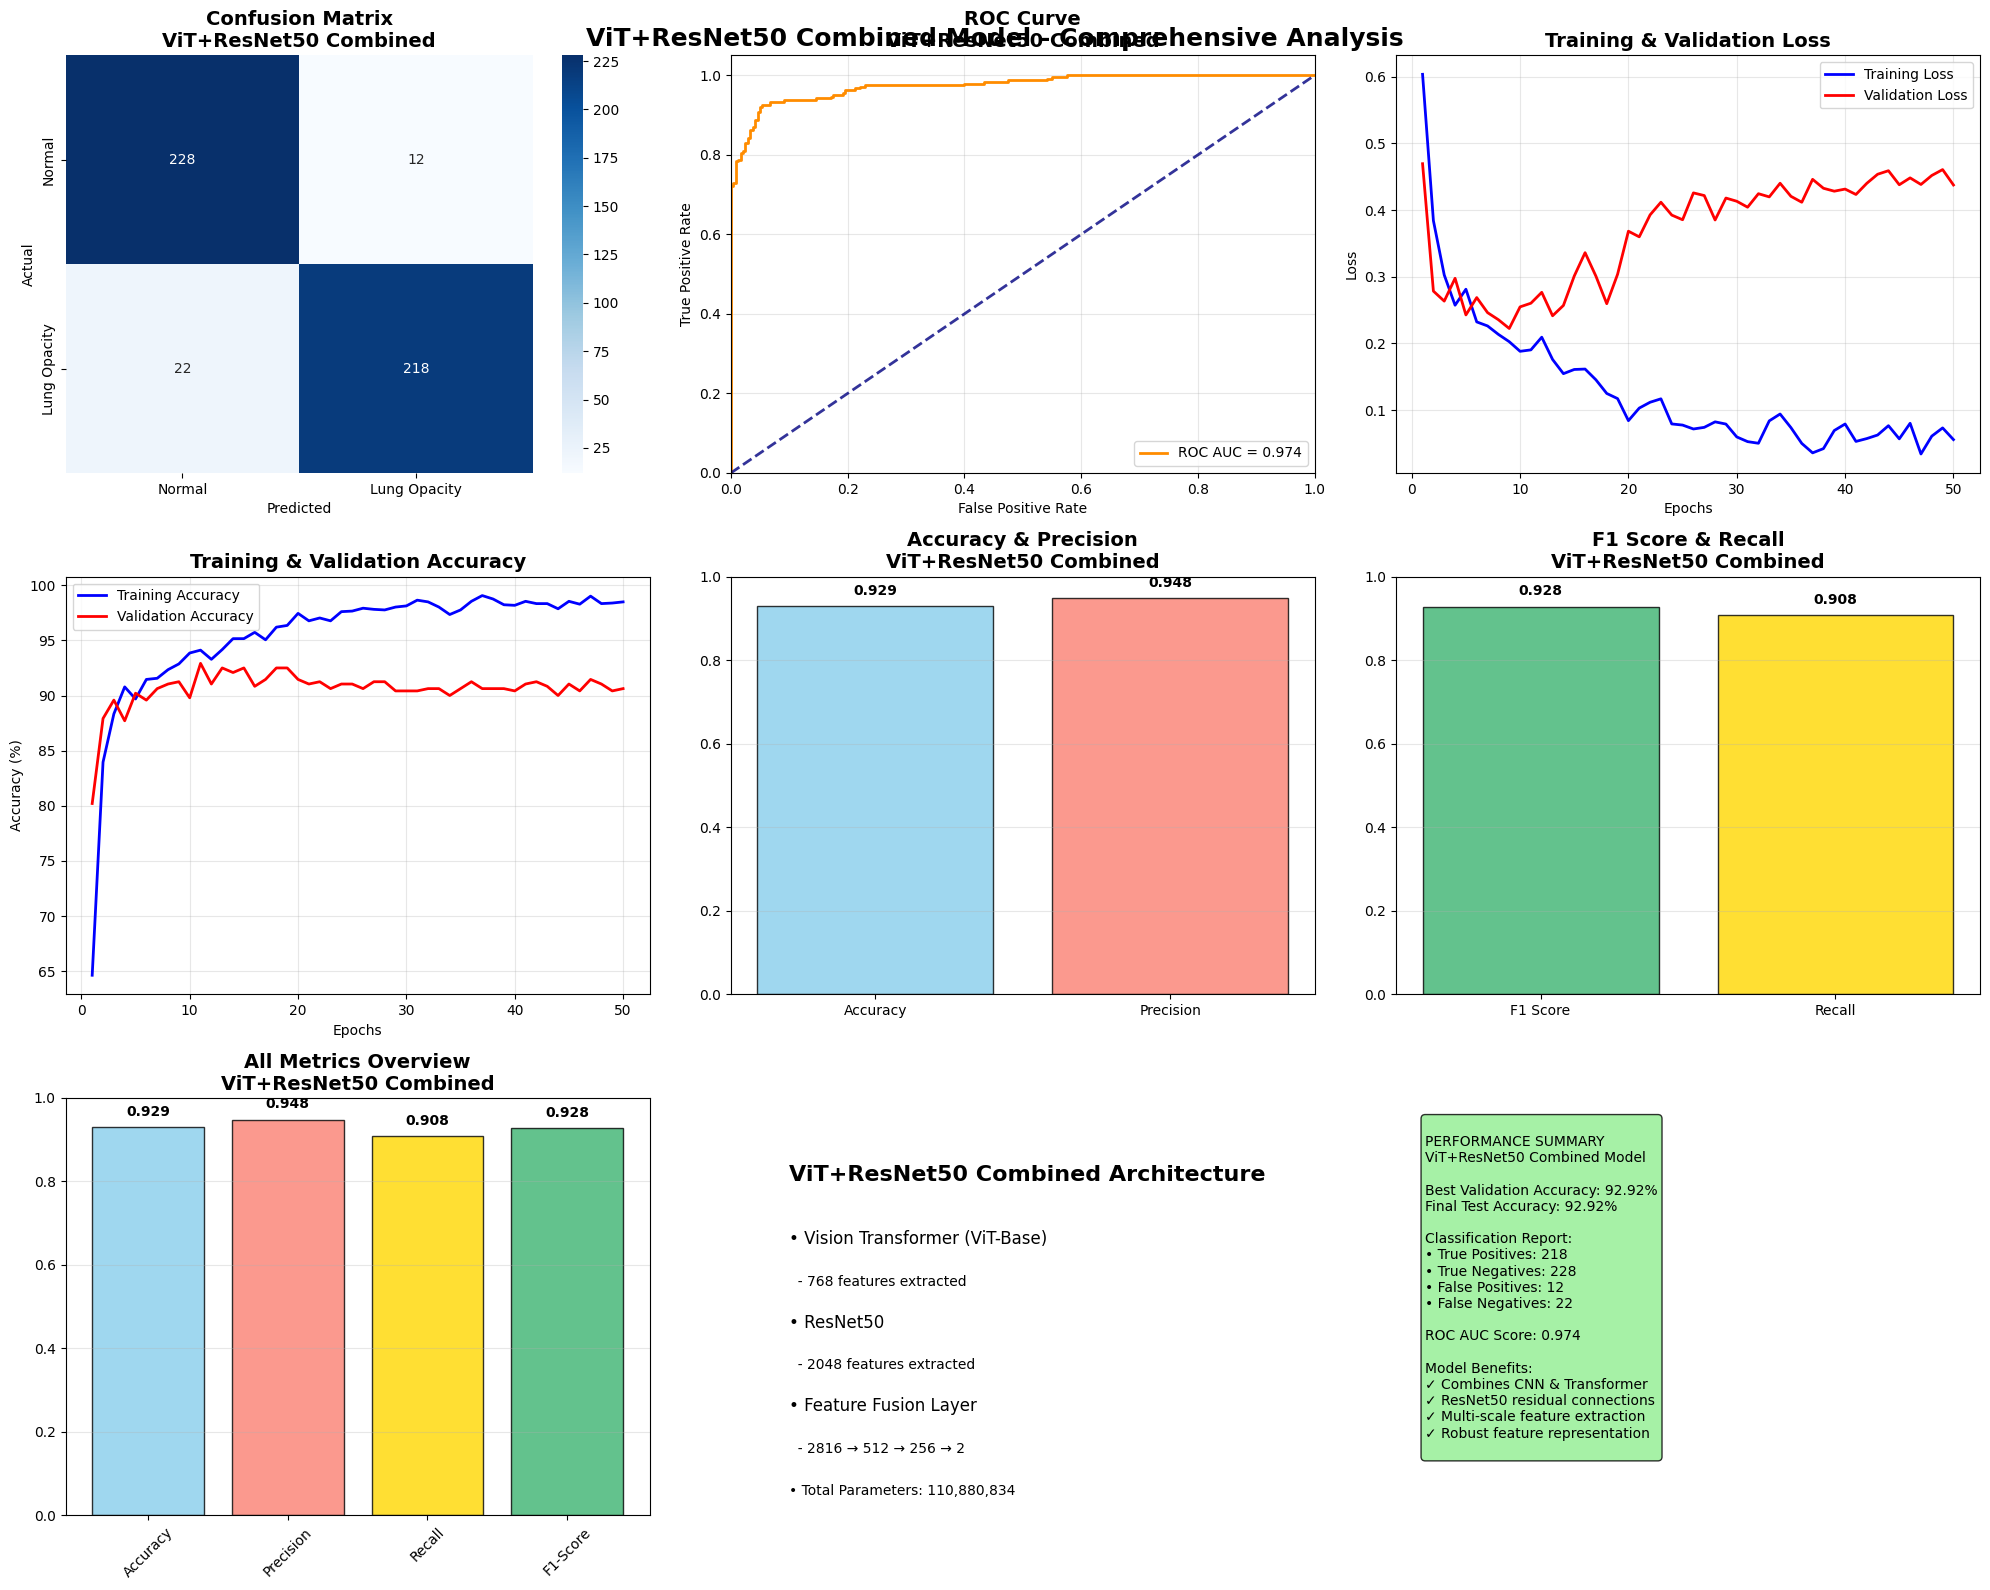


Model saved as: best_vit_resnet50_model.pth
Training completed successfully!
Results summary: {'model': 'ViT+ResNet50 Combined', 'final_accuracy': 0.9291666666666667, 'best_validation_accuracy': 0.9291666666666667, 'precision': 0.9478260869565217, 'recall': 0.9083333333333333, 'f1_score': 0.9276595744680851, 'roc_auc': np.float64(0.9741319444444444), 'total_parameters': 110880834, 'trainable_parameters': 110880834}


In [1]:
#VIT+RESNET50

import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, auc
)
import timm
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch.nn.functional as F
import cv2
import random

# Dataset class
class ChestXrayDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label, img_path

# Combined ViT + ResNet50 Model
class ViTResNet50Combined(nn.Module):
    def __init__(self, num_classes=2, dropout_rate=0.3):
        super(ViTResNet50Combined, self).__init__()
        
        # Vision Transformer branch
        self.vit = timm.create_model('vit_base_patch16_224', pretrained=True)
        vit_features = self.vit.head.in_features
        self.vit.head = nn.Identity()  # Remove the classification head
        
        # ResNet50 branch
        self.resnet50 = timm.create_model('resnet50', pretrained=True)
        resnet_features = self.resnet50.fc.in_features
        self.resnet50.fc = nn.Identity()  # Remove the classification head
        
        # Feature fusion layer
        combined_features = vit_features + resnet_features
        
        # Classification head with fusion
        self.fusion_layer = nn.Sequential(
            nn.Linear(combined_features, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )
        
        # Alternative: Attention-based fusion (uncomment to use)
        # self.attention = nn.MultiheadAttention(embed_dim=combined_features, num_heads=8, batch_first=True)
        # self.attention_fc = nn.Linear(combined_features, num_classes)
        
    def forward(self, x):
        # Extract features from both models
        vit_features = self.vit(x)  # [batch_size, 768]
        resnet_features = self.resnet50(x)  # [batch_size, 2048]
        
        # Concatenate features
        combined_features = torch.cat([vit_features, resnet_features], dim=1)
        
        # Classification
        output = self.fusion_layer(combined_features)
        
        # Alternative attention-based fusion (uncomment to use)
        # combined_features = combined_features.unsqueeze(1)  # Add sequence dimension
        # attended_features, _ = self.attention(combined_features, combined_features, combined_features)
        # attended_features = attended_features.squeeze(1)
        # output = self.attention_fc(attended_features)
        
        return output

# Paths
dataset_path = r"D:\Chest X-Ray Image\split"
train_normal = os.path.join(dataset_path, 'train', 'Normal')
train_lung_opacity = os.path.join(dataset_path, 'train', 'Lung_Opacity')
test_normal = os.path.join(dataset_path, 'test', 'Normal')
test_lung_opacity = os.path.join(dataset_path, 'test', 'Lung_Opacity')

train_images = [os.path.join(train_normal, img) for img in os.listdir(train_normal)] + \
               [os.path.join(train_lung_opacity, img) for img in os.listdir(train_lung_opacity)]
test_images = [os.path.join(test_normal, img) for img in os.listdir(test_normal)] + \
              [os.path.join(test_lung_opacity, img) for img in os.listdir(test_lung_opacity)]
train_labels = [0] * len(os.listdir(train_normal)) + [1] * len(os.listdir(train_lung_opacity))
test_labels = [0] * len(os.listdir(test_normal)) + [1] * len(os.listdir(test_lung_opacity))

# Enhanced transforms with data augmentation
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Dataset and loaders
train_dataset = ChestXrayDataset(train_images, train_labels, train_transform)
test_dataset = ChestXrayDataset(test_images, test_labels, test_transform)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)  # Reduced batch size due to model complexity
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Device and model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = ViTResNet50Combined(num_classes=2, dropout_rate=0.3)
model = model.to(device)

# Print model info
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Loss and optimizer with weight decay
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0001, weight_decay=0.01)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.5, verbose=True)

# Training & evaluation functions
def train_step(model, train_loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels, _ in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_acc = 100 * correct / total
    return running_loss / len(train_loader), train_acc

def evaluate(model, test_loader):
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    running_loss = 0.0
    
    with torch.no_grad():
        for images, labels, _ in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            
            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(probs, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs[:, 1].cpu().numpy())
    
    val_loss = running_loss / len(test_loader)
    return y_true, y_pred, y_prob, val_loss

# Training loop with best model saving
num_epochs = 50
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_acc = 0.0
save_path = "best_vit_resnet50_model.pth"

print("Starting training...")
print("="*50)

for epoch in range(num_epochs):
    # Training
    train_loss, train_acc = train_step(model, train_loader, optimizer, criterion)
    
    # Validation
    y_true, y_pred, _, val_loss = evaluate(model, test_loader)
    val_acc = accuracy_score(y_true, y_pred) * 100
    
    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_acc': best_acc,
        }, save_path)
        print(f"✓ New best model saved with accuracy: {best_acc:.2f}%")
    
    # Learning rate scheduling
    scheduler.step(val_acc)
    
    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    
    print(f"Epoch {epoch+1:2d}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

print("="*50)
print("Training completed!")

# Load best model for final evaluation
checkpoint = torch.load(save_path)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1} with accuracy: {checkpoint['best_acc']:.2f}%")

# Final evaluation
y_true, y_pred, y_prob, _ = evaluate(model, test_loader)

# Calculate metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"\n{'='*50}")
print("FINAL RESULTS - ViT+ResNet50 Combined Model")
print(f"{'='*50}")
print(f"Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"{'='*50}")

# Visualization
plt.style.use('default')
fig = plt.figure(figsize=(20, 16))

# 1. Confusion Matrix
plt.subplot(3, 3, 1)
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Normal", "Lung Opacity"], 
            yticklabels=["Normal", "Lung Opacity"])
plt.title("Confusion Matrix\nViT+ResNet50 Combined", fontsize=14, fontweight='bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")

# 2. ROC Curve
plt.subplot(3, 3, 2)
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', alpha=0.8)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve\nViT+ResNet50 Combined', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# 3. Training/Validation Loss
plt.subplot(3, 3, 3)
epochs_range = range(1, len(train_losses) + 1)
plt.plot(epochs_range, train_losses, 'b-', label='Training Loss', linewidth=2)
plt.plot(epochs_range, val_losses, 'r-', label='Validation Loss', linewidth=2)
plt.title('Training & Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Training/Validation Accuracy
plt.subplot(3, 3, 4)
plt.plot(epochs_range, train_accuracies, 'b-', label='Training Accuracy', linewidth=2)
plt.plot(epochs_range, val_accuracies, 'r-', label='Validation Accuracy', linewidth=2)
plt.title('Training & Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)

# 5. Metrics Bar Chart 1
plt.subplot(3, 3, 5)
metrics1 = ['Accuracy', 'Precision']
values1 = [acc, prec]
colors1 = ['skyblue', 'salmon']
bars1 = plt.bar(metrics1, values1, color=colors1, alpha=0.8, edgecolor='black')
plt.title('Accuracy & Precision\nViT+ResNet50 Combined', fontsize=14, fontweight='bold')
plt.ylim([0, 1])
for i, (bar, val) in enumerate(zip(bars1, values1)):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}', 
             ha='center', va='bottom', fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

# 6. Metrics Bar Chart 2
plt.subplot(3, 3, 6)
metrics2 = ['F1 Score', 'Recall']
values2 = [f1, rec]
colors2 = ['mediumseagreen', 'gold']
bars2 = plt.bar(metrics2, values2, color=colors2, alpha=0.8, edgecolor='black')
plt.title('F1 Score & Recall\nViT+ResNet50 Combined', fontsize=14, fontweight='bold')
plt.ylim([0, 1])
for i, (bar, val) in enumerate(zip(bars2, values2)):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}', 
             ha='center', va='bottom', fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

# 7. All Metrics Comparison
plt.subplot(3, 3, 7)
all_metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
all_values = [acc, prec, rec, f1]
colors_all = ['skyblue', 'salmon', 'gold', 'mediumseagreen']
bars_all = plt.bar(all_metrics, all_values, color=colors_all, alpha=0.8, edgecolor='black')
plt.title('All Metrics Overview\nViT+ResNet50 Combined', fontsize=14, fontweight='bold')
plt.ylim([0, 1])
plt.xticks(rotation=45)
for i, (bar, val) in enumerate(zip(bars_all, all_values)):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}', 
             ha='center', va='bottom', fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

# 8. Model Architecture Visualization (Text-based)
plt.subplot(3, 3, 8)
plt.text(0.1, 0.8, 'ViT+ResNet50 Combined Architecture', fontsize=16, fontweight='bold')
plt.text(0.1, 0.65, '• Vision Transformer (ViT-Base)', fontsize=12)
plt.text(0.1, 0.55, '  - 768 features extracted', fontsize=10)
plt.text(0.1, 0.45, '• ResNet50', fontsize=12)
plt.text(0.1, 0.35, '  - 2048 features extracted', fontsize=10)
plt.text(0.1, 0.25, '• Feature Fusion Layer', fontsize=12)
plt.text(0.1, 0.15, '  - 2816 → 512 → 256 → 2', fontsize=10)
plt.text(0.1, 0.05, f'• Total Parameters: {total_params:,}', fontsize=10)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.axis('off')

# 9. Performance Summary
plt.subplot(3, 3, 9)
summary_text = f"""
PERFORMANCE SUMMARY
ViT+ResNet50 Combined Model

Best Validation Accuracy: {best_acc:.2f}%
Final Test Accuracy: {acc*100:.2f}%

Classification Report:
• True Positives: {cm[1,1]}
• True Negatives: {cm[0,0]}  
• False Positives: {cm[0,1]}
• False Negatives: {cm[1,0]}

ROC AUC Score: {roc_auc:.3f}

Model Benefits:
✓ Combines CNN & Transformer
✓ ResNet50 residual connections
✓ Multi-scale feature extraction
✓ Robust feature representation
"""
plt.text(0.05, 0.95, summary_text, fontsize=10, verticalalignment='top', 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.8))
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.axis('off')

plt.tight_layout()
plt.suptitle('ViT+ResNet50 Combined Model - Comprehensive Analysis', 
             fontsize=18, fontweight='bold', y=0.98)
plt.show()

# Save detailed results
results_summary = {
    'model': 'ViT+ResNet50 Combined',
    'final_accuracy': acc,
    'best_validation_accuracy': best_acc/100,
    'precision': prec,
    'recall': rec,
    'f1_score': f1,
    'roc_auc': roc_auc,
    'total_parameters': total_params,
    'trainable_parameters': trainable_params
}

print(f"\nModel saved as: {save_path}")
print("Training completed successfully!")
print(f"Results summary: {results_summary}")

c:\Users\saiga\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Total parameters: 90,987,134
Trainable parameters: 90,987,134
Starting training...


c:\Users\saiga\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


✓ New best model saved with accuracy: 89.58%
Epoch  1/50 | Train Loss: 0.4174 | Train Acc: 80.26% | Val Loss: 0.2566 | Val Acc: 89.58%
✓ New best model saved with accuracy: 91.46%
Epoch  2/50 | Train Loss: 0.2061 | Train Acc: 92.45% | Val Loss: 0.2353 | Val Acc: 91.46%
Epoch  3/50 | Train Loss: 0.1548 | Train Acc: 94.74% | Val Loss: 0.2653 | Val Acc: 91.04%
✓ New best model saved with accuracy: 92.08%
Epoch  4/50 | Train Loss: 0.1325 | Train Acc: 95.78% | Val Loss: 0.2751 | Val Acc: 92.08%
Epoch  5/50 | Train Loss: 0.0985 | Train Acc: 96.61% | Val Loss: 0.2866 | Val Acc: 91.25%
Epoch  6/50 | Train Loss: 0.1047 | Train Acc: 96.93% | Val Loss: 0.3717 | Val Acc: 90.21%
✓ New best model saved with accuracy: 92.50%
Epoch  7/50 | Train Loss: 0.0841 | Train Acc: 97.40% | Val Loss: 0.2707 | Val Acc: 92.50%
Epoch  8/50 | Train Loss: 0.0591 | Train Acc: 98.18% | Val Loss: 0.3945 | Val Acc: 91.88%
Epoch  9/50 | Train Loss: 0.0420 | Train Acc: 98.70% | Val Loss: 0.4472 | Val Acc: 90.42%
✓ New best

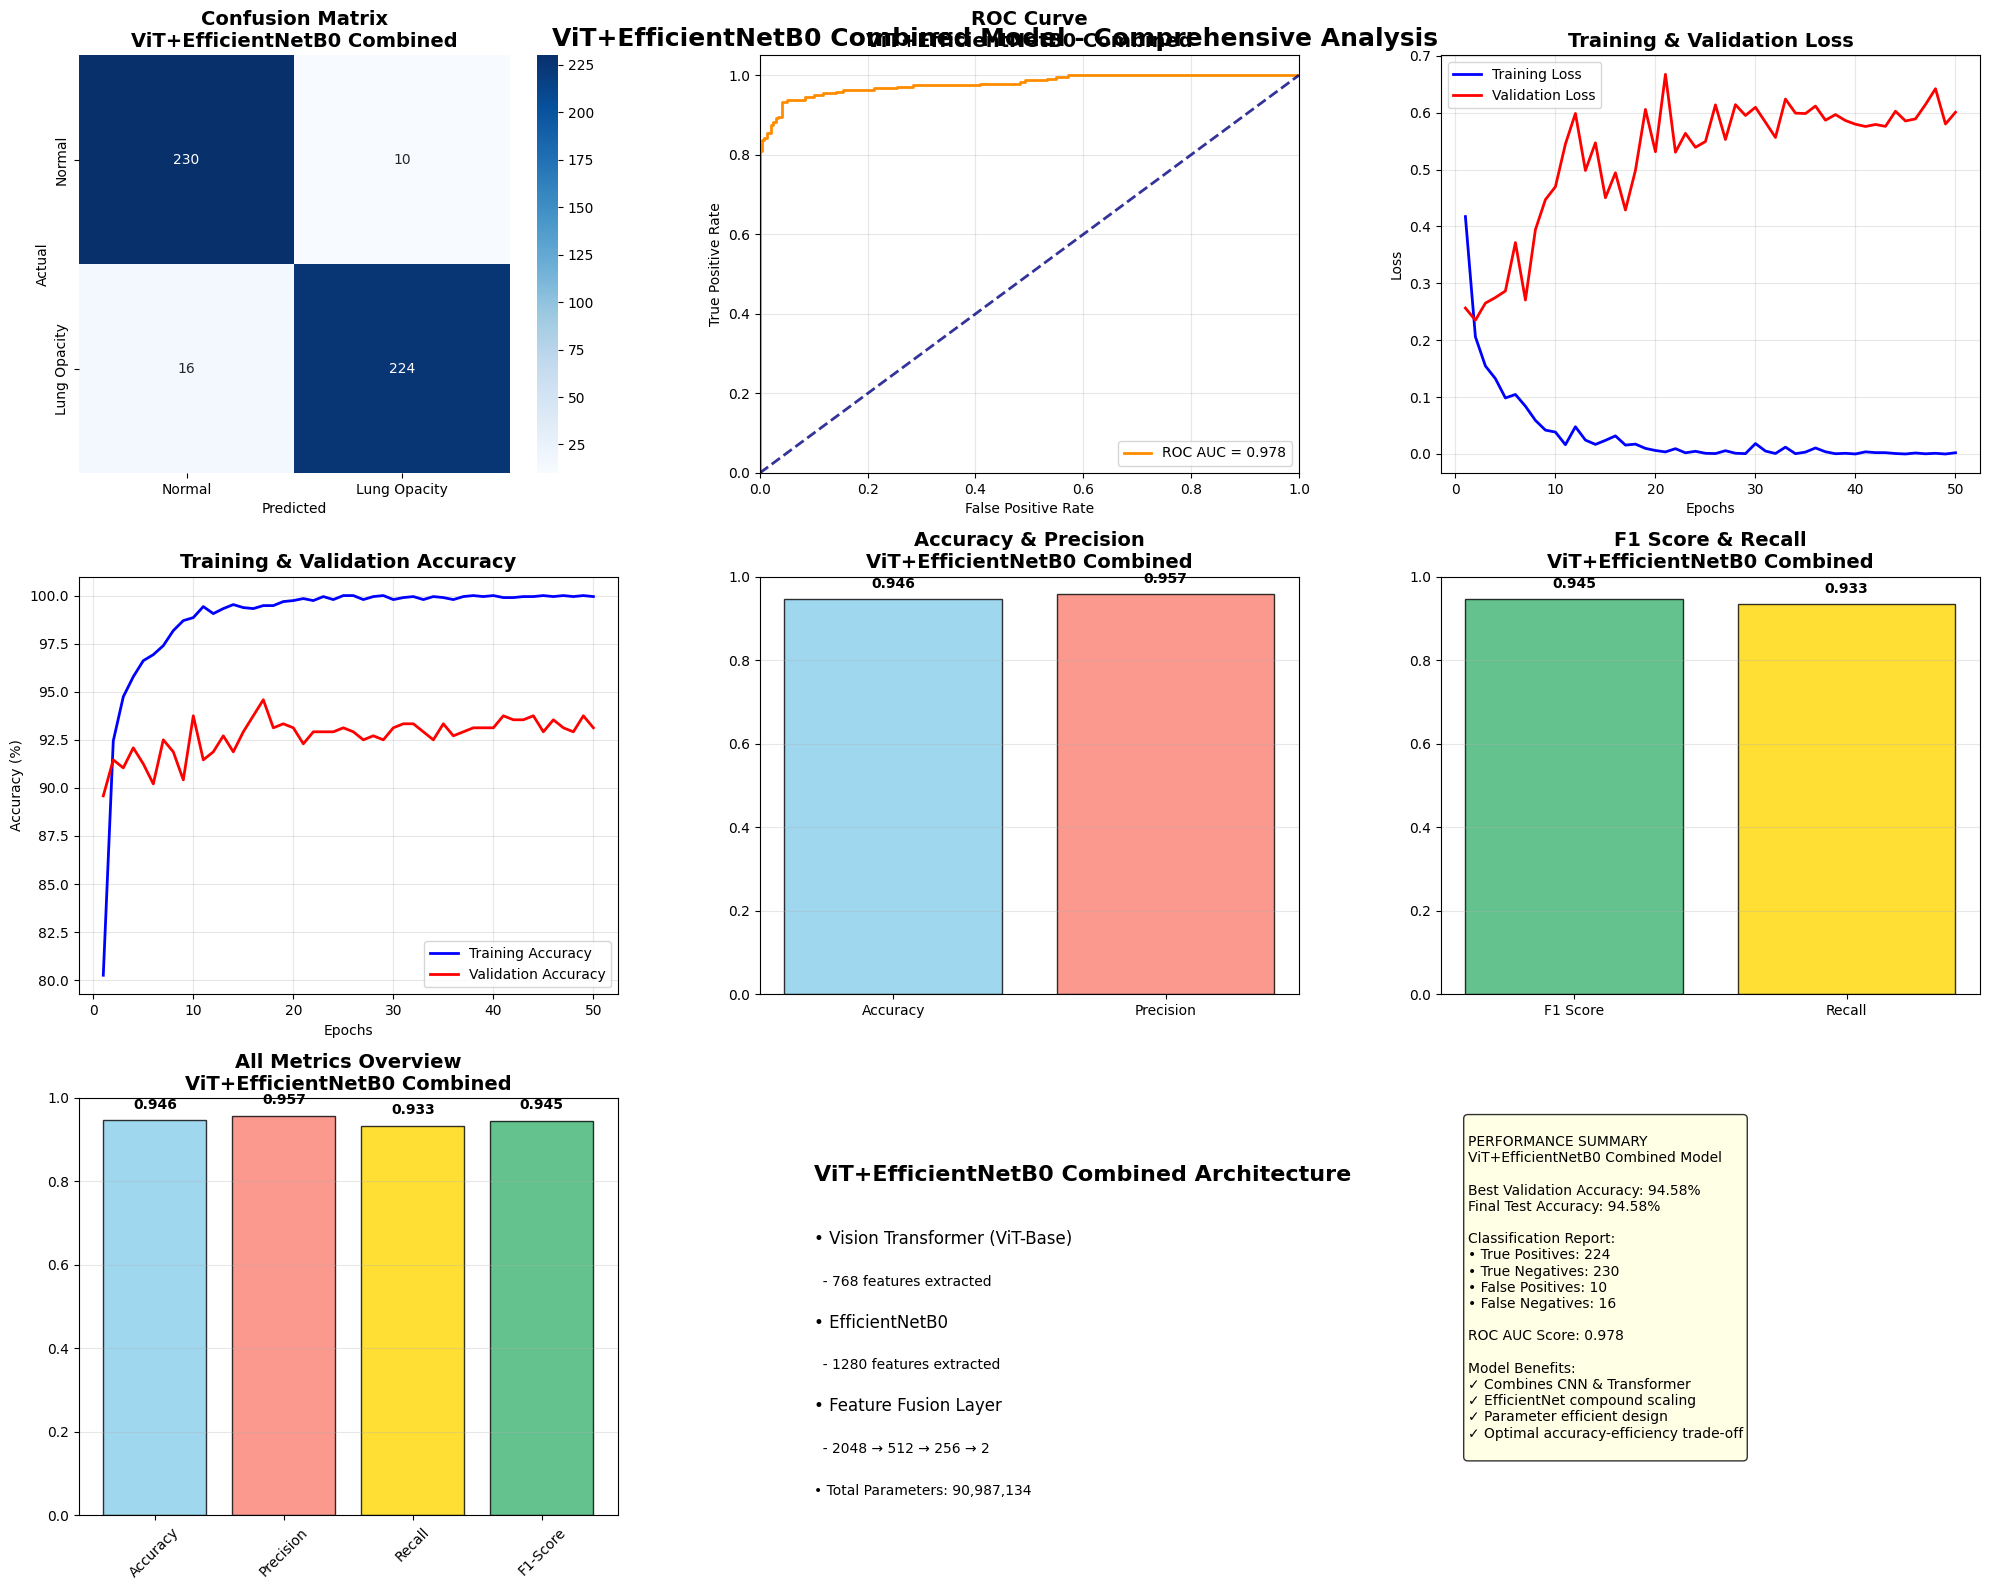


Model saved as: best_vit_efficientnetb0_model.pth
Training completed successfully!
Results summary: {'model': 'ViT+EfficientNetB0 Combined', 'final_accuracy': 0.9458333333333333, 'best_validation_accuracy': 0.9458333333333333, 'precision': 0.9572649572649573, 'recall': 0.9333333333333333, 'f1_score': 0.9451476793248945, 'roc_auc': np.float64(0.97828125), 'total_parameters': 90987134, 'trainable_parameters': 90987134}
